In [43]:
!pip install gensim

ERROR! Session/line number was not unique in database. History logging moved to new session 138


In [44]:
import warnings
warnings.filterwarnings("ignore")

from gensim.models import Word2Vec, FastText
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("Kütüphaneler yüklendi!")

Kütüphaneler yüklendi!


In [45]:
import pandas as pd
from meta import *

df = pd.read_csv(datapath+"\IMDB.csv")["review"]

df.info()

<class 'pandas.core.series.Series'>
RangeIndex: 50000 entries, 0 to 49999
Series name: review
Non-Null Count  Dtype 
--------------  ----- 
50000 non-null  object
dtypes: object(1)
memory usage: 390.8+ KB


In [46]:
for sample in df.sample(5):
    print(sample)
    print("Sample Len:", len(sample))

Like the previous two 'Mad Max' films, 'Mad Max Beyond Thunderdome' is not exception to the violence and strange plot. Mad Max is in a post-war society where he must destroy master blaster and get the children to 'tomorrow morrow land'. This is generally a warped film with Peter Pan references and Tina Turner, methane-pigs, and odd characters. I got very bored by watching it all, and it offered nothing to me. I did not feel inspired after watching this film; the only decent thing about this film were the extremely-odd characters that got picked off in various ways throughout the film. It's too weird for me, and it was much too dull.
Sample Len: 640
I get really fed up with sitcoms; you feel you always know what is coming so it ceases to be funny. On the other hand, Hi De Hi, you rarely know what is coming and it's laugh out loud funny. I have just purchased the second set of the series, (series 3 -4)and I am surprised at just how much I am enjoying it all - again. I have nothing but pr

In [47]:
import re
from collections import Counter
import pandas as pd

def clean_text(text, remove_numbers=False):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    if remove_numbers:
        text = re.sub(r"\d+", " ", text)

    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize_text(text):
    return [token for token in text.split() if len(token) >= 3]


remove_numbers_option = False
min_count = 3

cleaned = df.apply(lambda x: clean_text(x, remove_numbers=remove_numbers_option))

tokenized = cleaned.apply(tokenize_text)

word_counts = Counter()

for sentence in tokenized:
    word_counts.update(sentence)

tokenized = tokenized.apply(
    lambda sentence: [
        word for word in sentence
        if word_counts[word] >= min_count
    ]
)

cleaned = tokenized.apply(" ".join)

df = pd.DataFrame({
    "original": df,
    "cleaned": cleaned,
    "tokenized": tokenized,
})

df.head()

,original,cleaned,tokenized
0,One of the other reviewers has mentioned that ...,one the other reviewers has mentioned that aft...,"[one, the, other, reviewers, has, mentioned, t..."
1,A wonderful little production. <br /><br />The...,wonderful little production the filming techni...,"[wonderful, little, production, the, filming, ..."
2,I thought this was a wonderful way to spend ti...,thought this was wonderful way spend time too ...,"[thought, this, was, wonderful, way, spend, ti..."
3,Basically there's a family where a little boy ...,basically there family where little boy jake t...,"[basically, there, family, where, little, boy,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",mattei love the time money visually stunning f...,"[mattei, love, the, time, money, visually, stu..."


In [48]:
df.to_csv(datapath+"/IMDB_prep.csv", index=False, encoding="utf-8")

In [49]:
tokens = df.tokenized

In [50]:
model_sg = Word2Vec(
    tokens,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    epochs=10,
    workers=4,
    seed=42
)

model_cbow = Word2Vec(
    tokens,
    vector_size=100,
    window=5,
    min_count=5,
    sg=0,
    epochs=10,
    workers=4,
    seed=42
)

In [51]:
print(f"Kelime hazinesi boyutu: {len(model_sg.wv)}")
print(f"Vektör boyutu: {model_sg.wv.vector_size}")

Kelime hazinesi boyutu: 39225
Vektör boyutu: 100


In [52]:
kelime = "movie"
vektor = model_sg.wv[kelime]
print(f"'{kelime}' kelimesinin vektörü (ilk 10 eleman):")
print(np.round(vektor[:10], 3))
print(f"\nVektör şekli: {vektor.shape}")

print("\n--- 'movie' kelimesine en benzer kelimeler ---")
benzerler = model_sg.wv.most_similar(kelime, topn=3)
for kelime, skor in benzerler:
    print(f"  {kelime:15s}  benzerlik: {skor:.4f}")

'movie' kelimesinin vektörü (ilk 10 eleman):
[ 0.104  0.206  0.252  0.076 -0.131  0.317  0.054  0.062 -0.202 -0.058]

Vektör şekli: (100,)

--- 'movie' kelimesine en benzer kelimeler ---
  film             benzerlik: 0.8926
  sequal           benzerlik: 0.7567
  flick            benzerlik: 0.7542


In [53]:
# Kelimeler arası benzerlik skoru
pairs = [
    ("movie", "film"),
    ("good", "great"),
    ("watch", "see"),
    ("okay", "fine"),
    ("like", "enjoy"),
    ("bad", "cool")
]

print("Kelime çiftleri arasındaki benzerlik:")
print(f"{'Çift':<30} {'Benzerlik':>10}")
print("-" * 42)
for k1, k2 in pairs:
    skor = model_sg.wv.similarity(k1, k2)
    bar = "█" * int(skor * 20)
    print(f"({k1}, {k2}){'':<15} {skor:>6.4f}  {bar}")


Kelime çiftleri arasındaki benzerlik:
Çift                            Benzerlik
------------------------------------------
(movie, film)                0.8926  █████████████████
(good, great)                0.7586  ███████████████
(watch, see)                0.7186  ██████████████
(okay, fine)                0.5374  ██████████
(like, enjoy)                0.4894  █████████
(bad, cool)                0.4899  █████████


In [54]:
print("=== Vektör Aritmetiği ===\n")

sonuc = model_sg.wv.most_similar(
    positive=["movie", "action"],  # ekle
    negative=["film"],          # çıkar
    topn=3
)

for kelime, skor in sonuc:
    print(f"  → {kelime:15s}  ({skor:.4f})")

print()


=== Vektör Aritmetiği ===

  → gunfights        (0.6361)
  → swordplay        (0.6330)
  → honk             (0.6239)



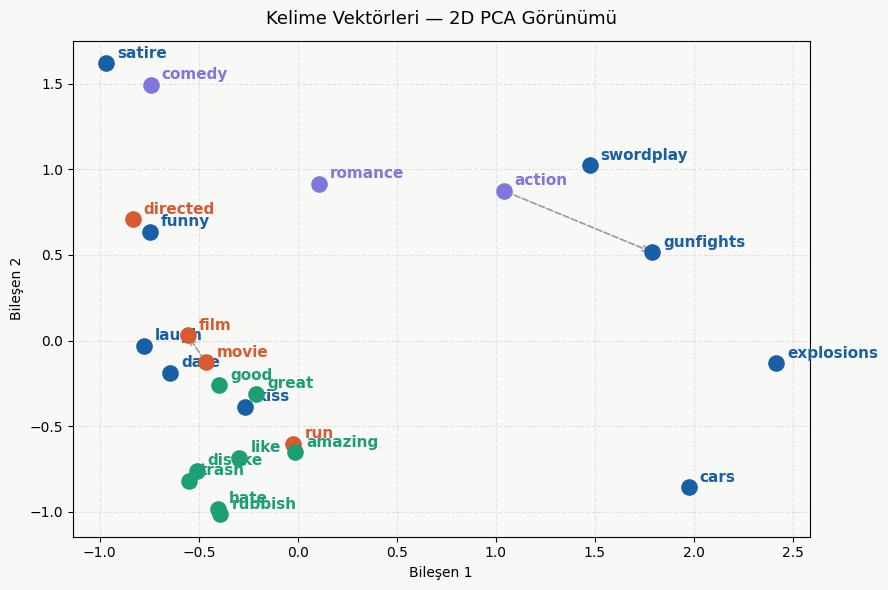

In [55]:
from sklearn.decomposition import PCA

kelimeler = ["movie", "film", "good", "great", 
             "like", "action", "romance", "swordplay",
             "explosions", "gunfights", "kiss",
             "run", "directed", "hate","dislike","trash",
             "rubbish", "amazing", "date","cars",
             "comedy","funny","laugh","satire"]

vektorler = np.array([model_sg.wv[k] for k in kelimeler])

pca = PCA(n_components=2, random_state=42)
vek_2d = pca.fit_transform(vektorler)

renkler = {
    "genre": ("#7F77DD", ["action", "romance", "comedy"]),
    "name":  ("#D85A30", ["movie", "film", "run", "directed"]),
    "sentiment": ("#1D9E75", ["good", "great", "like", "hate", "dislike", "trash", "rubbish", "amazing"]),
    "content": ("#185FA5", ["swordplay", "explosions","gunfights","kiss","date","cars","funny","laugh","satire"]),
}

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor("#f8f8f6")
fig.patch.set_facecolor("#f8f8f6")

for grup, (renk, grup_kelimeleri) in renkler.items():
    for kw in grup_kelimeleri:
        idx = kelimeler.index(kw)
        x, y = vek_2d[idx]
        ax.scatter(x, y, color=renk, s=120, zorder=5)
        ax.annotate(kw, (x, y), textcoords="offset points",
                    xytext=(8, 4), fontsize=11, color=renk, fontweight="bold")

for k1, k2 in [("movie", "film"), ("action", "gunfights")]:
    i1, i2 = kelimeler.index(k1), kelimeler.index(k2)
    ax.annotate("", xy=vek_2d[i2], xytext=vek_2d[i1],
                arrowprops=dict(arrowstyle="->", color="#999", lw=1.2, linestyle="dashed"))

ax.set_title("Kelime Vektörleri — 2D PCA Görünümü", fontsize=13, pad=12)
ax.set_xlabel("Bileşen 1"); ax.set_ylabel("Bileşen 2")
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()
